<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install tensorflow

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.1-cp313-cp313-win_amd64.whl.metadata (32 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   -----------------

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [20]:
import os
import platform
import zipfile

# Descargar la carpeta de dataset si no existe
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        print("Descargando el dataset...")
        if platform.system() == 'Windows':
            # En Windows modernos 'curl' funciona nativamente con -L para seguir redirecciones
            !curl -L https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
            
    # Descomprimir usando Python puro (Evita el error de "unzip")
    print("Descomprimiendo archivo...")
    with zipfile.ZipFile('songs_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("¡Dataset listo para usar!")
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [21]:
# Posibles bandas
os.listdir("./songs_dataset/")

['adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt',
 'cake.txt',
 'dickinson.txt',
 'disney.txt',
 'dj-khaled.txt',
 'dolly-parton.txt',
 'dr-seuss.txt',
 'drake.txt',
 'eminem.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'johnny-cash.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'kanye.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'leonard-cohen.txt',
 'lil-wayne.txt',
 'Lil_Wayne.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'ludacris.txt',
 'michael-jackson.txt',
 'missy-elliott.txt',
 'nickelback.txt',
 'nicki-minaj.txt',
 'nirvana.txt',
 'notorious-big.txt',
 'notorious_big.txt',
 'nursery_rhymes.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'r-kelly.txt',
 'radiohead.txt',
 'rihanna.txt']

In [22]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

C:\Users\franc\AppData\Local\Temp\ipykernel_3024\3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [23]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [24]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [25]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [26]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [27]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [28]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [29]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [30]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [31]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.2421875
Loss after epoch 1: 65966.5390625
Loss after epoch 2: 65934.96875
Loss after epoch 3: 65718.46875
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.96875
Loss after epoch 6: 64080.34375
Loss after epoch 7: 64815.0
Loss after epoch 8: 62632.5625
Loss after epoch 9: 60452.6875
Loss after epoch 10: 59839.6875
Loss after epoch 11: 58884.1875
Loss after epoch 12: 57715.9375
Loss after epoch 13: 56494.0
Loss after epoch 14: 55817.4375
Loss after epoch 15: 55843.0
Loss after epoch 16: 51722.5
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.125
Loss after epoch 19: 48960.375


(156986, 287740)

### 4 - Ensayar

In [32]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954252004623413),
 ('sleep', 0.8665635585784912),
 ('help', 0.8439401388168335),
 ('cry', 0.8351266980171204),
 ('not', 0.8309596180915833),
 ('try', 0.8276923298835754),
 ('peace', 0.8144838809967041),
 ('little', 0.8140546679496765),
 ('twist', 0.8123899102210999),
 ('seems', 0.8079549670219421)]

In [33]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873109579086304),
 ('four', -0.2330222725868225),
 ('five', -0.23746439814567566),
 ('six', -0.2378462553024292),
 ('bang', -0.24832230806350708),
 ('our', -0.2553924024105072),
 ('day', -0.26898154616355896),
 ('going', -0.2692105174064636),
 ('here', -0.26990070939064026),
 ('three', -0.2838965952396393)]

In [34]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.981372058391571),
 ('three', 0.9745771288871765),
 ('six', 0.9710806608200073),
 ('seven', 0.9584371447563171),
 ('two', 0.951723575592041),
 ('sixty', 0.8990399241447449),
 ('one', 0.7951170802116394),
 ('crying', 0.7946274876594543),
 ('us', 0.7740071415901184),
 ("i'm", 0.7508386969566345)]

In [35]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434005618095398),
 ('buy', 0.9396992921829224),
 ('much', 0.9033195376396179),
 ('just', 0.8509086966514587),
 ('hide', 0.8355351090431213)]

In [37]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138413  0.05881019 -0.06370354  0.02445617 -0.20152482 -0.18611853
 -0.15284552  0.45486635 -0.04217679  0.03535806  0.13657518 -0.18519785
 -0.18126503  0.22149378 -0.30380824 -0.23969936  0.07094827 -0.0567887
 -0.05165625 -0.2384332  -0.08529592  0.19564067 -0.07679196  0.03796551
  0.0751621  -0.0482575   0.07379384  0.10396665  0.00737955 -0.22764955
 -0.04567023  0.12936655  0.27785373  0.19387273 -0.13510206  0.20857345
  0.40917116 -0.00386532 -0.10631495 -0.09056864  0.02401222 -0.08005036
  0.13399509  0.08833685 -0.01894409  0.08592524 -0.1590568   0.10259779
  0.14459649 -0.12092511 -0.27919346 -0.04061023  0.11382007  0.31366137
 -0.0740839   0.139766    0.22791134  0.13208385 -0.0181147   0.09772249
  0.09249445 -0.14871854 -0.163485   -0.1320215  -0.09834237  0.02714372
  0.16531056  0.26052314 -0.03259229 -0.02894631  0.11621047 -0.06974225
  0.09562858 -0.15276162  0.22070931  0.15996651  0.15890568 -0.04711937
 -0.12555729 -0.03992885 -0.10795498  0.01878585  0.

In [38]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085155129432678),
 ('someone', 0.8886152505874634),
 ('need', 0.8827986717224121),
 ('nothing', 0.8740267753601074),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526656031608582),
 ('you', 0.8456713557243347),
 ('feed', 0.8445046544075012),
 ('somebody', 0.8362797498703003)]

In [39]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085155129432678),
 ('someone', 0.8886152505874634),
 ('need', 0.8827986717224121),
 ('nothing', 0.8740267753601074),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526656627655029),
 ('you', 0.8456713557243347),
 ('feed', 0.844504714012146),
 ('somebody', 0.8362797498703003),
 ('buy', 0.8351762294769287)]

### 5 - Visualizar agrupación de vectores

In [40]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

In [44]:
import sys, subprocess, pkgutil
def install_if_missing(package, import_name=None):
    import_name = import_name or package
    if pkgutil.find_loader(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("beautifulsoup4", "bs4")
install_if_missing("lxml")
install_if_missing("plotly")
install_if_missing("gensim")

# Compatibilidad: algunas versiones de scipy pueden romper gensim.
try:
    from gensim.models import Word2Vec
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy<1.14", "gensim==4.3.3"])
    from gensim.models import Word2Vec

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from gensim.models.callbacks import CallbackAny2Vec

C:\Users\franc\AppData\Local\Temp\ipykernel_3024\1827512167.py:4: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader(import_name) is None:


### Cargo el CORPUS

In [48]:
EPUB_PATH = "texto.epub"

if not os.path.exists(EPUB_PATH):
    raise FileNotFoundError(
        "No se encontró texto.epub. Subí el archivo al mismo directorio del notebook y volvé a ejecutar."
    )

def extract_text_from_epub(epub_path):
    """Extrae texto plano desde archivos HTML/XHTML contenidos en un EPUB."""
    texts = []

    with zipfile.ZipFile(epub_path, "r") as z:
        html_files = [
            name for name in z.namelist()
            if name.lower().endswith((".html", ".xhtml", ".htm"))
        ]

        for name in html_files:
            raw = z.read(name)
            soup = BeautifulSoup(raw, "lxml")

            for tag in soup(["script", "style", "nav"]):
                tag.decompose()

            text = soup.get_text(separator=" ")
            text = re.sub(r"\s+", " ", text).strip()

            if len(text) > 100:
                texts.append(text)

    return " ".join(texts)

raw_text = extract_text_from_epub(EPUB_PATH)

print("Cantidad de caracteres extraídos:", len(raw_text))
print(raw_text[:1000])

C:\Users\franc\AppData\Local\Temp\ipykernel_3024\1704697005.py:20: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  soup = BeautifulSoup(raw, "lxml")


Cantidad de caracteres extraídos: 503311
The Project Gutenberg eBook of Essentials of Diseases of the Skin, by Henry Weightman Stelwagon The Project Gutenberg eBook of Essentials of Diseases of the Skin This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever. You may copy it, give it away or re-use it under the terms of the Project Gutenberg License included with this eBook or online at www.gutenberg.org . If you are not located in the United States, you will have to check the laws of the country where you are located before using this eBook. Title : Essentials of Diseases of the Skin Author : Henry Weightman Stelwagon Release date : July 1, 2008 [eBook #25944] Language : English Other information and formats : www.gutenberg.org/ebooks/25944 Credits : E-text prepared by Kevin Handy, Ronnie Sahlberg, cbott, John Hagerson, and the Project Gutenberg Online Distributed Proofreading Team *** ST

### Preprocesamiento
Antes de entrenar el Word2Vec, realizo preprocesamiento. El mismo se basará en pasar en eliminar palabras comunes cortas y stepwords, pasar todo a minúscula, conservar palabras alfabéticas y eliminar números y signos de puntuación. 

In [ ]:
STOPWORDS_EN = set("""
a about above after again against all am an and any are as at be because been before being below between both but by
can did do does doing down during each few for from further had has have having he her here hers herself him himself his
how i if in into is it its itself just me more most my myself no nor not now of off on once only or other our ours ourselves
out over own same she should so some such than that the their theirs them themselves then there these they this those through
to too under until up very was we were what when where which while who whom why will with you your yours yourself yourselves
""".split())

# Stopwords frecuentes del texto que no aportan semántica específica.
EXTRA_STOPWORDS = set("""
project gutenberg ebook chapter page copyright edition volume section figure table illustration
""".split())
STOPWORDS = STOPWORDS_EN | EXTRA_STOPWORDS


def split_sentences(text):
    """Separo texto en oraciones de forma simple usando signos de puntuación."""
    sentences = re.split(r"[.!?;:]+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


def tokenize_sentence(sentence):
    """Tokeniza y limpia una oración."""
    sentence = sentence.lower()
    tokens = re.findall(r"[a-z]+", sentence)
    tokens = [tok for tok in tokens if len(tok) > 2 and tok not in STOPWORDS]
    return tokens

sentences_raw = split_sentences(raw_text)
sentence_tokens = [tokenize_sentence(s) for s in sentences_raw]
sentence_tokens = [s for s in sentence_tokens if len(s) >= 3]

print("Cantidad de oraciones/documentos:", len(sentence_tokens))
print("Ejemplo de oración tokenizada:")
print(sentence_tokens[0])

Cantidad de oraciones/documentos: 4562
Ejemplo de oración tokenizada:
['essentials', 'diseases', 'skin', 'henry', 'weightman', 'stelwagon', 'essentials', 'diseases', 'skin', 'use', 'anyone', 'anywhere', 'united', 'states', 'parts', 'world', 'cost', 'almost', 'restrictions', 'whatsoever']


In [51]:
# Análisis descriptivo simple del corpus
all_tokens = [tok for sent in sentence_tokens for tok in sent]
unique_tokens = sorted(set(all_tokens))

print("Cantidad total de tokens:", len(all_tokens))
print("Cantidad de palabras únicas:", len(unique_tokens))

freq = pd.Series(all_tokens).value_counts()
freq.head(20)

Cantidad total de tokens: 41512
Cantidad de palabras únicas: 5579


may           595
usually       460
disease       336
cases         258
treatment     251
skin          235
upon          225
several       223
one           218
lesions       197
symptoms      190
less          184
parts         182
eruption      173
also          165
describe      164
eczema        158
often         153
especially    144
general       143
Name: count, dtype: int64

### Entrenamiento de Word2Vec
Se entrena el modelo Word2Vec con arquitectura Skip-gram.  Esta variante intenta predecir palabras de contexto a partir de una palabra central, y suele funcionar bien para capturar relaciones semánticas con corpus mediana.

In [52]:
class LossLogger(CallbackAny2Vec):
    """Callback para mostrar la pérdida aproximada al final de cada época."""
    def __init__(self):
        self.epoch = 0
        self.loss_previous_step = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        epoch_loss = loss - self.loss_previous_step
        print(f"Loss epoch {self.epoch}: {epoch_loss:.2f}")
        self.loss_previous_step = loss
        self.epoch += 1

In [53]:
# Parámetros principales del modelo
w2v_model = Word2Vec(
    min_count=3,       # incluye palabras que aparecen al menos 3 veces
    window=5,          # contexto de 5 palabras antes/después
    vector_size=100,   # dimensión del embedding
    negative=10,       # negative sampling
    workers=1,         # reproducibilidad
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    seed=42
)

w2v_model.build_vocab(sentence_tokens)

print("Cantidad de oraciones en el corpus:", w2v_model.corpus_count)
print("Cantidad de palabras en el vocabulario:", len(w2v_model.wv.index_to_key))
print("Primeras 30 palabras del vocabulario:")
print(w2v_model.wv.index_to_key[:30])

Cantidad de oraciones en el corpus: 4562
Cantidad de palabras en el vocabulario: 2610
Primeras 30 palabras del vocabulario:
['may', 'usually', 'disease', 'cases', 'treatment', 'skin', 'upon', 'several', 'one', 'lesions', 'symptoms', 'less', 'parts', 'eruption', 'also', 'describe', 'eczema', 'often', 'especially', 'general', 'course', 'instances', 'inflammatory', 'ointment', 'new', 'rule', 'applications', 'patches', 'acid', 'hair']


In [55]:
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=50,
    compute_loss=True,
    callbacks=[LossLogger()]
)

Loss epoch 0: 290572.59
Loss epoch 1: 286363.47
Loss epoch 2: 278424.00
Loss epoch 3: 270036.19
Loss epoch 4: 261215.62
Loss epoch 5: 255611.38
Loss epoch 6: 252470.00
Loss epoch 7: 247305.00
Loss epoch 8: 236285.00
Loss epoch 9: 233589.75
Loss epoch 10: 232619.25
Loss epoch 11: 228425.75
Loss epoch 12: 228416.50
Loss epoch 13: 224056.50
Loss epoch 14: 224559.00
Loss epoch 15: 222678.00
Loss epoch 16: 222575.50
Loss epoch 17: 206369.00
Loss epoch 18: 204090.50
Loss epoch 19: 205328.00
Loss epoch 20: 203328.50
Loss epoch 21: 202714.50
Loss epoch 22: 202791.00
Loss epoch 23: 201591.50
Loss epoch 24: 201122.00
Loss epoch 25: 201647.00
Loss epoch 26: 199513.50
Loss epoch 27: 198163.00
Loss epoch 28: 198471.50
Loss epoch 29: 197737.50
Loss epoch 30: 196496.00
Loss epoch 31: 195673.00
Loss epoch 32: 194333.50
Loss epoch 33: 195467.50
Loss epoch 34: 194541.50
Loss epoch 35: 193836.50
Loss epoch 36: 193274.00
Loss epoch 37: 192017.50
Loss epoch 38: 173067.50
Loss epoch 39: 171911.00
Loss epoch

(1767496, 2075600)

El vocabulario queda limitado por `min_count=3`, lo que evita que palabras muy raras o errores aislados entren al modelo. El parámetro `window=5` define el tamaño del contexto que Word2Vec observa alrededor de cada palabra. Por lo tanto, las relaciones aprendidas no dependen de definiciones externas, sino de coocurrencias dentro del propio libro.

### Búsqueda de terminos similares

In [58]:
def available_words(candidates, model):
    """Devuelve candidatos presentes en el vocabulario."""
    return [w for w in candidates if w in model.wv]

candidate_terms = [
    "skin", "disease", "inflammation", "eruption", "eczema", "patient", "treatment",
    "scalp", "face", "hands", "itching", "lesion"]

terms = available_words(candidate_terms, w2v_model)
print("Términos disponibles seleccionados:", terms)

if len(terms) < 5:
    # Si el EPUB tuviera otro contenido, se eligen palabras frecuentes automáticamente.
    terms = w2v_model.wv.index_to_key[:8]
    print("No se encontraron suficientes términos candidatos; se usan frecuentes:", terms)

Términos disponibles seleccionados: ['skin', 'disease', 'inflammation', 'eruption', 'eczema', 'patient', 'treatment', 'scalp', 'face', 'hands', 'itching', 'lesion']


In [59]:
similarity_tables = {}

for term in terms[:8]:
    sims = w2v_model.wv.most_similar(positive=[term], topn=10)
    df_sims = pd.DataFrame(sims, columns=["palabra_similar", "similitud_coseno"])
    similarity_tables[term] = df_sims
    print("" + "="*70)
    print(f"Palabras más similares a: {term}")
    display(df_sims)

Palabras más similares a: skin


,palabra_similar,similitud_coseno
0,fig,0.466436
1,senile,0.462988
2,parchment,0.462119
3,pigmentosum,0.453620
4,essentials,0.452681
5,atrophied,0.439149
6,xeroderma,0.437596
7,overlying,0.425165
8,anatomy,0.418720
9,neighboring,0.412560


Palabras más similares a: disease


,palabra_similar,similitud_coseno
0,infancy,0.495374
1,adult,0.464910
2,sclerema,0.463508
3,scleroderma,0.455854
4,childhood,0.443958
5,contagious,0.438675
6,less,0.438392
7,usually,0.436585
8,pellagra,0.434875
9,birth,0.432190


Palabras más similares a: inflammation


...

,palabra_similar,similitud_coseno
0,bearing,0.536927
1,verrucosa,0.494402
2,details,0.490533
3,operation,0.481184
4,careful,0.470242
5,stage,0.467968
6,tuberculosis,0.463783
7,touching,0.462009
8,considering,0.462004
9,hygienic,0.453012


Palabras más similares a: treatment


,palabra_similar,similitud_coseno
0,palliation,0.490943
1,guarded,0.484491
2,advise,0.482890
3,irresponsive,0.481993
4,directed,0.465483
5,rest,0.461982
6,unsatisfactory,0.459752
7,medication,0.459433
8,hygiene,0.450627
9,measures,0.447942


Palabras más similares a: scalp


,palabra_similar,similitud_coseno
0,involving,0.512890
1,eyebrows,0.486211
2,scrotum,0.471714
3,favus,0.468042
4,bearded,0.451256
5,buttocks,0.442783
6,ringworm,0.441013
7,palms,0.435368
8,seborrh,0.430050
9,invaded,0.414084


Podemos observar que las palabras similares, no son sinónimos. Word2Vec aprende similitud distribucional, es decir, nos dice que dos palabras son cercanas si aparecen en cotextos parecidos.

### Búsqueda de terminos menos similares

In [60]:
def least_similar_words(model, word, topn=10):
    """Devuelve las palabras con menor similitud coseno respecto de una palabra dada."""
    if word not in model.wv:
        raise ValueError(f"La palabra '{word}' no está en el vocabulario")
    words = model.wv.index_to_key
    sims = model.wv.cosine_similarities(model.wv[word], model.wv.vectors)
    df = pd.DataFrame({"palabra": words, "similitud_coseno": sims})
    df = df[df["palabra"] != word]
    return df.sort_values("similitud_coseno", ascending=True).head(topn).reset_index(drop=True)

for term in terms[:5]:
    print("" + "="*70)
    print(f"Palabras menos similares a: {term}")
    display(least_similar_words(w2v_model, term, topn=10))

Palabras menos similares a: skin


,palabra,similitud_coseno
0,full,-0.099480
1,makes,-0.084370
2,considered,-0.072983
3,might,-0.050276
4,toward,-0.049875
5,must,-0.048305
6,even,-0.045654
7,excellent,-0.044137
8,things,-0.041427
9,important,-0.035536


Palabras menos similares a: disease


,palabra,similitud_coseno
0,fine,-0.054861
1,use,-0.045741
2,representing,-0.033360
3,full,-0.020859
4,strong,-0.020158
5,practically,-0.019583
6,needle,-0.014835
7,also,-0.013975
8,applying,-0.001453
9,straight,-0.000427


Palabras menos similares a: inflammation


,palabra,similitud_coseno
0,means,-0.094833
1,base,-0.093990
2,necessary,-0.090425
3,coming,-0.086317
4,particular,-0.085270
5,venereal,-0.084783
6,breaking,-0.073381
7,based,-0.060921
8,aid,-0.052730
9,borne,-0.052060


Palabras menos similares a: eruption


,palabra,similitud_coseno
0,case,-0.073195
1,operative,-0.071999
2,punctate,-0.058428
3,different,-0.055216
4,also,-0.042223
5,locally,-0.037562
6,prevent,-0.029590
7,previous,-0.028026
8,papilla,-0.024848
9,light,-0.023077


Palabras menos similares a: eczema


,palabra,similitud_coseno
0,gives,-0.054146
1,noted,-0.029933
2,contain,-0.029407
3,pressed,-0.025398
4,elevation,-0.023158
5,crust,-0.022030
6,lowest,-0.020397
7,seconds,-0.018738
8,round,-0.015559
9,every,-0.013674


Las palabras menos similares suelen pertenecer a regiones semánticas alejadas del término evaluado. 

### Reducción dimensional y visualización 2D
Los embeddings entrenados tienen 100 dimensiones. Para visualizarlos se reduce su dimensionalidad a 2D usando t-SNE. El gráfico permite inspeccionar agrupaciones locales de palabras.

In [61]:
from sklearn.manifold import TSNE
import plotly.express as px

MAX_WORDS = min(250, len(w2v_model.wv.index_to_key))

vectors = np.asarray(w2v_model.wv.vectors[:MAX_WORDS])
labels = np.asarray(w2v_model.wv.index_to_key[:MAX_WORDS])

perplexity = min(30, max(5, (MAX_WORDS - 1) // 3))

tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity
)
vecs_2d = tsne.fit_transform(vectors)

plot_df = pd.DataFrame({
    "x": vecs_2d[:, 0],
    "y": vecs_2d[:, 1],
    "palabra": labels
})

fig = px.scatter(plot_df, x="x", y="y", text="palabra", title="Embeddings Word2Vec proyectados a 2D con t-SNE")
fig.update_traces(textposition="top center", marker=dict(size=6))
fig.update_layout(width=1000, height=750)
fig.show()

En el gráfico se espera observar pequeñas agrupaciones de palabras asociadas por contexto. Un ejemplo claro es en el cuadrante superior izquierdo, que tenemos muy cercanas las palabras 'portion' y 'central', palabras muy utilizadas en conjunto para determinar una ubicacion especifica de un órgano, hueso, etc. del cuerpo humano en libros de ciencias médicas.

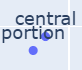

Otro ejemplo claro es 'surface', 'affected' y 'acne': conjunto de palabras que están altamente relacionadas.

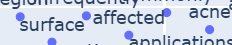

### Visualización con PCA

In [62]:
pca = PCA(n_components=2, random_state=42)
vecs_pca = pca.fit_transform(vectors)

pca_df = pd.DataFrame({
    "x": vecs_pca[:, 0],
    "y": vecs_pca[:, 1],
    "palabra": labels
})

fig = px.scatter(pca_df, x="x", y="y", text="palabra", title="Embeddings Word2Vec proyectados a 2D con PCA")
fig.update_traces(textposition="top center", marker=dict(size=6))
fig.update_layout(width=1000, height=750)
fig.show()

print("Varianza explicada por PCA:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada por PCA: [0.03917902 0.03081009]
Varianza explicada acumulada: 0.069989115


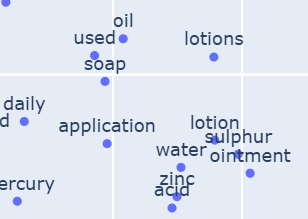

Podemos observar que con el PCA se hace un poco más dificil el análisis del embedding, pero en la parte derecha podemos observar un buen funcionamiento del modelo.

También se observa proximidad entre 'oil' y 'lotions', reforzando la idea de que el modelo logró agrupar términos pertenecientes a una misma temática.

Por otro lado, palabras como 'sulphur' y 'ointment' también presentan cercanía, posiblemente debido a contextos vinculados con tratamientos medicinales o dermatológicos.

Y por último, 'zinc' y 'mercury' relativamente cercanos que también presentan una relación semántica entre ellos.

### Interpretación PCA vs t-SNE
PCA es útil para observar una estructura global aproximada, pero puede perder relaciones locales sutiles. Mientras que t-SNE suele ser más conveniente para inspeccionar grupos pequeños de palabras similares. Por este motivo, para el análisis de embedding, a veces resulta más conveniente el uso de t-SNE. 